# ResNet

In [1]:
import time

import torch
import torchvision
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import transforms
import matplotlib.pyplot as plt
from torchsummary import summary
from tqdm.notebook import tqdm


In this notebook, we will implementing ResNet18 which is a deep convolutional neural network (CNN) that is part of the ResNet (Residual Network) family, introduced by Kaiming He et al. in their landmark paper “Deep Residual Learning for Image Recognition” in 2015. ResNet models address the vanishing gradient problem, which makes it difficult to train deep networks.

For more details, try checking out the [original ResNet paper](https://arxiv.org/pdf/1512.03385.pdf) or [this fantastic blog post](https://towardsdatascience.com/understanding-and-visualizing-resnets-442284831be8).

## Key Concepts:
- **Vanishing Gradient Problem**: As neural networks get deeper, they tend to suffer from vanishing or exploding gradients. This means that during backpropagation, the gradients of the loss function with respect to earlier layers become very small (or very large), making learning inefficient or unstable.

- **Residual Learning**: The core idea behind ResNet is the introduction of residual blocks. Instead of each layer simply learning a direct mapping, $H(𝑥)$, the residual block learns a residual mapping, $𝐹(𝑥)=𝐻(𝑥)−𝑥$. The network then reuses the input via a skip connection, meaning the layer effectively learns $𝐻(𝑥)=𝐹(𝑥)+𝑥$. This makes it easier for the network to learn identity mappings, allowing for very deep networks without suffering from the vanishing gradient problem.

## Types of Skip Connections in ResNet:
1. **Identity Skip Connection (Without Change in Dimensions):**

    If the input and output dimensions of a block match, the skip connection is straightforward. The input is directly added to the output of the residual block: $𝑦=𝐹(𝑥)+𝑥$ where $𝐹(𝑥)$ is the residual function, typically two convolutional layers.

3. **Skip Connection with Dimension Mismatch (Projection Shortcut):**

   If the input and output dimensions don’t match (e.g., due to striding or increasing the number of channels), a direct addition isn’t possible. In this case, ResNet uses a projection shortcut to match dimensions, typically with a 1x1 convolution:

$$\begin{aligned}
𝑦=𝐹(𝑥)+𝑊_sx
\end{aligned}$$

where 𝑊<sub>s</sub> is a 1x1 convolution layer used to adjust the dimensions of the input $x$ to match those of the output.

In this notebook, we are going to implement ResNet18.

# ResNet18 Architecture

ResNet18 is a relatively shallow version of the ResNet model with 18 layers. The structure is as follows:

#### Input Layer
- The input image (typically **224x224x3** for RGB) is passed through a **7x7 convolutional layer** with 64 filters and a stride of 2.
- Followed by **batch normalization** and a **max pooling layer**.
- This step reduces the spatial dimensions to **112x112x64**.

#### Residual Blocks
ResNet18 has **4 stages** of residual blocks, with each stage containing **2 residual blocks**. A residual block typically consists of **2 convolutional layers** (3x3 convolutions).

- **Stage 1 (conv2_x)**: 2 blocks with **64 filters**.
- **Stage 2 (conv3_x)**: 2 blocks with **128 filters**.
- **Stage 3 (conv4_x)**: 2 blocks with **256 filters**.
- **Stage 4 (conv5_x)**: 2 blocks with **512 filters**.

Each residual block consists of:
- Two **3x3 convolutional layers** followed by **batch normalization** and **ReLU activation**.
- A **skip connection** (identity mapping) from the input of the block directly to the output.

#### Fully Connected Layer
- After the last residual block, the output is passed through a **global average pooling layer** that reduces the dimensions and prepares the data for the final classification.
- The pooled output is then fed into a **fully connected (FC) layer**, typically with **1000 output units** (for classification on the ImageNet dataset).
- This implementation uses CIFAR10 dataset, so we have 10 output units. 


In [2]:
class ResNetBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        '''
        The expected network structure:
        - conv layer with
            out_channels=out_channels, 3x3 kernel, stride=stride
        - batchnorm layer (Batchnorm2D)
        - conv layer with
            out_channels=out_channels, 3x3 kernel, stride=1
        - batchnorm layer (Batchnorm2D)
        - shortcut layer:
            if either the stride is not 1 or the out_channels is not equal to in_channels:
                the shortcut layer is composed of two steps:
                - conv layer with
                    in_channels=in_channels, out_channels=out_channels, 1x1 kernel, stride=stride
                - batchnorm layer (Batchnorm2D)
            else:
                the shortcut layer should be an no-op

        All conv layers will have a padding of 1 and no bias term.
        When performing a forward pass, the ReLU activation should be applied after the first batchnorm layer
        and after the second batchnorm gets added to the shortcut.
        '''
        super(ResNetBlock, self).__init__()
        self.conv1 = self.conv(in_channels, out_channels, 3, stride = stride)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = self.conv(out_channels, out_channels, 3, stride = 1)
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                self.conv(in_channels,
                     out_channels,
                     kernel_size=3, stride=stride),
                nn.BatchNorm2d(out_channels),
            )

    def conv(self, in_channels, out_channels, kernel_size, stride):
        return nn.Conv2d(in_channels, out_channels, kernel_size, stride, padding=1, bias=False)

    def forward(self, x):
        '''
        Compute a forward pass of this batch of data on this residual block.

        x: batch of images of shape (batch_size, num_channels, width, height)
        returns: result of passing x through this block
        '''
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        out = F.relu(out)
        return out

Now, we write the ResNet18 Architecture. 

In [3]:
class ResNet18(nn.Module):
    def __init__(self, num_classes, in_channels):
        super(ResNet18, self).__init__()
        self.num_classes = num_classes
        self.in_channels = 64
        self.conv1 = nn.Conv2d(in_channels=3,
                               out_channels=64,
                               kernel_size=3,
                               stride=1,
                               padding=1,
                               bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.layer1 = self.make_block(out_channels=64, stride=1)
        self.layer2 = self.make_block(out_channels=128, stride=2)
        self.layer3 = self.make_block(out_channels=256, stride=2)
        self.layer4 = self.make_block(out_channels=512, stride=2)
        self.linear = nn.Linear(512, num_classes)

    def make_block(self, out_channels, stride):
        layers = []
        for stride in [stride, 1]:
            layers.append(ResNetBlock(self.in_channels, out_channels, stride))
            self.in_channels = out_channels
        return nn.Sequential(*layers)

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))    # 112x112x64
        x = self.layer1(x)                     # 56x56x64
        x = self.layer2(x)                     # 28x28x128
        x = self.layer3(x)                     # 14x14x256
        x = self.layer4(x)                     # 7x7x512 
        x = F.avg_pool2d(x, 4)                 # 1x1x512
        x = torch.flatten(x, 1)                # 512, 
        x = self.linear(x)                     # 10,
        return x

Let's check if the model we create is correct. For this we will be using torch summary. 

In [4]:
# We want to train our model on a hardware accelerator like the GPU, if it is available.
use_cuda = torch.cuda.is_available()
if use_cuda:
    device = torch.device("cuda")
else:
    device = torch.device("cpu")
print(f"Using {device} device")

num_classes = 10
resnet = ResNet18(num_classes, 64)
summary(resnet, (3,32,32))

Using cuda device
Layer (type:depth-idx)                   Output Shape              Param #
├─Conv2d: 1-1                            [-1, 64, 32, 32]          1,728
├─BatchNorm2d: 1-2                       [-1, 64, 32, 32]          128
├─Sequential: 1-3                        [-1, 64, 32, 32]          --
|    └─ResNetBlock: 2-1                  [-1, 64, 32, 32]          --
|    |    └─Conv2d: 3-1                  [-1, 64, 32, 32]          36,864
|    |    └─BatchNorm2d: 3-2             [-1, 64, 32, 32]          128
|    |    └─Conv2d: 3-3                  [-1, 64, 32, 32]          36,864
|    |    └─BatchNorm2d: 3-4             [-1, 64, 32, 32]          128
|    |    └─Sequential: 3-5              [-1, 64, 32, 32]          --
|    └─ResNetBlock: 2-2                  [-1, 64, 32, 32]          --
|    |    └─Conv2d: 3-6                  [-1, 64, 32, 32]          36,864
|    |    └─BatchNorm2d: 3-7             [-1, 64, 32, 32]          128
|    |    └─Conv2d: 3-8                  [-1, 64

Layer (type:depth-idx)                   Output Shape              Param #
├─Conv2d: 1-1                            [-1, 64, 32, 32]          1,728
├─BatchNorm2d: 1-2                       [-1, 64, 32, 32]          128
├─Sequential: 1-3                        [-1, 64, 32, 32]          --
|    └─ResNetBlock: 2-1                  [-1, 64, 32, 32]          --
|    |    └─Conv2d: 3-1                  [-1, 64, 32, 32]          36,864
|    |    └─BatchNorm2d: 3-2             [-1, 64, 32, 32]          128
|    |    └─Conv2d: 3-3                  [-1, 64, 32, 32]          36,864
|    |    └─BatchNorm2d: 3-4             [-1, 64, 32, 32]          128
|    |    └─Sequential: 3-5              [-1, 64, 32, 32]          --
|    └─ResNetBlock: 2-2                  [-1, 64, 32, 32]          --
|    |    └─Conv2d: 3-6                  [-1, 64, 32, 32]          36,864
|    |    └─BatchNorm2d: 3-7             [-1, 64, 32, 32]          128
|    |    └─Conv2d: 3-8                  [-1, 64, 32, 32]         

## Load the Dataset

In [5]:
batch_size = 512
pretrained_means = [0.485, 0.456, 0.406]
pretrained_stds = [0.229, 0.224, 0.225]
train_size = 40_000
val_size = 10_000
data_root = "./data/cifar10"
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=pretrained_means, std=pretrained_stds),
])
classes = (
    'plane', 'car', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck',
)

In [6]:
dataset = torchvision.datasets.CIFAR10(
    root=data_root,
    train=True,
    download=True,
    transform=transform,
)
train_set, val_set, _ = torch.utils.data.random_split(
    dataset, [train_size, val_size, len(dataset) - train_size - val_size]
)

test_set = torchvision.datasets.CIFAR10(
    root=data_root,
    train=False,
    download=True,
    transform=transform,
)

Files already downloaded and verified
Files already downloaded and verified


In [7]:
train_loader = torch.utils.data.DataLoader(
    train_set,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
)
val_loader = torch.utils.data.DataLoader(
    val_set,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
)
test_loader = torch.utils.data.DataLoader(
    test_set,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
)

In [8]:
print(f'Size of train loader = {len(train_loader)}') # ceil(len(training_set) / batch_size)
print(f'Size of validation loader = {len(val_loader)}')
print(f'Size of test loader = {len(test_loader)}')

Size of train loader = 79
Size of validation loader = 20
Size of test loader = 20


One Batch Dimension = torch.Size([512, 3, 32, 32]), Labels Dimension = torch.Size([512])


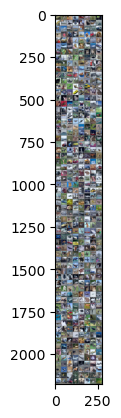

In [9]:

# Helper function for inline image display
def normalize_image(image):
    image_min = image.min()
    image_max = image.max()
    image.clamp_(min=image_min, max=image_max)
    image.add_(-image_min).div_(image_max - image_min + 1e-5)
    return image

def matplotlib_imshow(img):
    img = normalize_image(img)
    img = img.permute((1,2,0))
    npimg = img.numpy()
    plt.imshow(npimg)
    
# Extract a batch of images
dataiter = iter(train_loader)
images, labels = next(dataiter)

print(f'One Batch Dimension = {images.shape}, Labels Dimension = {labels.shape}')

# Create a grid from the images and show them
img_grid = torchvision.utils.make_grid(images)
matplotlib_imshow(img_grid)

### Training

In [10]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

In [11]:
def compute_accuracy(model, val_loader):
    total_correct = 0
    model = model.to(device)
    model.eval()
    for inputs, labels in tqdm(val_loader, leave=False):
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        outputs = outputs.argmax(1)
        correct = (outputs == labels)
        total_correct += correct.sum()
    return total_correct / len(val_loader.dataset)

In [12]:
def train(model, train_loader, val_loader, num_epochs, criterion, optimizer, checkpoint_directory):
    print('beginning to train model')
    model = model.to(device)
    model.train()
    for epoch in tqdm(range(num_epochs)):
        total_loss = 0
        for inputs, labels in tqdm(train_loader, leave=False):
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss
        train_acc = compute_accuracy(model, train_loader)
        val_acc = compute_accuracy(model, val_loader)

        print(f'epoch {epoch:2}',
              f'loss: {total_loss:.3f}',
              f'train acc: {train_acc:.4f}',
              f'val acc: {val_acc:.4f}', sep='\t')
        # save the checkpoint
        checkpoint = {
            'epoch' : epoch,
            'model_state_dict' : model.state_dict(),
            'optimizer_state_dict' : optimizer.state_dict(),
            'train_loss' : train_acc,
            'val_loss' : val_acc
        }
        torch.save(checkpoint, checkpoint_directory + '/resnet.pt')

In [13]:
num_epochs = 30
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(resnet.parameters(), lr=1e-3)
checkpoint_directory = "./models/resnet/"
train(resnet, train_loader, val_loader, num_epochs, criterion, optimizer, checkpoint_directory)

beginning to train model


  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/79 [00:00<?, ?it/s]

  0%|          | 0/79 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

...

epoch 28	loss: 5.949	train acc: 0.9867	val acc: 0.6497


  0%|          | 0/79 [00:00<?, ?it/s]

  0%|          | 0/79 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

epoch 29	loss: 4.668	train acc: 0.9959	val acc: 0.6602


## Load the trained model and test

In [13]:
state = torch.load('./models/resnet/resnet.pt', weights_only=False)
resnet.load_state_dict(state['model_state_dict'])

<All keys matched successfully>

In [14]:
transform = transforms.Compose([
  transforms.ToTensor(),
  transforms.Normalize(pretrained_means, pretrained_stds),
])
cifar_test = torchvision.datasets.CIFAR10(
    root=data_root,
    train=False,
    download=True,
    transform=transform,
)
loader_test = torch.utils.data.DataLoader(cifar_test, batch_size=batch_size, shuffle=False)

Files already downloaded and verified


In [15]:
resnet.eval()  # set model to evaluation mode
predictions = []
test_acc = compute_accuracy(resnet, loader_test)
print(f"The test accuracy is : {test_acc}")

  0%|          | 0/20 [00:00<?, ?it/s]

The test accuracy is : 0.6502000093460083
